# Is nuclear *cleaner* than wind or solar? A decision-analytic rebuttal

**Claim under test:** *“Nuclear power plants produce cleaner energy than wind or solar panels, and the data confirm it.”*

The claim is a **ranking statement under a single, undefined objective**. We treat it as three falsifiable questions and answer each with explicit uncertainty:

| # | Question | Method |
|---|----------|--------|
| Q1 | Is nuclear unambiguously lower-carbon than wind/solar? | Lifecycle GHG distributions + pairwise dominance probabilities |
| Q2 | Is there a single “cleanest” technology once “clean” is operationalised? | 12-metric scoring, Monte-Carlo uncertainty, **global** weight-space sensitivity |
| Q3 | Is the answer stable across *where* and *when* you build? | Region counterfactuals, cost-of-capital break-evens, grid/year marginal abatement |

**Stance.** Nuclear is a genuinely low-carbon source; this is not an anti-nuclear analysis. The target is the *epistemics* of the claim: it collapses a high-dimensional, uncertain, context-dependent comparison into a single ranking. We show where that fails and quantify by how much.

References: [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md) · [`data/data_sources.md`](../data/data_sources.md) · [`docs/methods_note.md`](../docs/methods_note.md) · [`docs/claim_to_evidence.md`](../docs/claim_to_evidence.md).

In [1]:
%matplotlib inline
import hashlib
import platform
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from energy_cleanliness.data import load_lifecycle_data
from energy_cleanliness.analysis import (
    compare_to_baseline, simulate_uncertainty, estimate_pairwise_probabilities,
)
from energy_cleanliness.multimetric import METRIC_UNITS, load_multimetric_profile, higher_is_better_set, to_wide
from energy_cleanliness.scenarios import SCENARIOS, get_scenario
from energy_cleanliness.cleanliness_index import (
    monte_carlo_cleanliness, pareto_frontier, normalize_cleanliness_matrix,
)
from energy_cleanliness.regions import run_region_scenarios
from energy_cleanliness.financing import DEFAULT_TECHNO_ECONOMICS, DEFAULT_ENVIRONMENTS, lcoe
from energy_cleanliness.geography import load_grid_intensity, trajectory_table, grid_intensity

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

# Stable colour identity for technologies across every figure.
_PALETTE = plt.cm.tab20(np.linspace(0, 1, 20))
def tech_color(name, _cache={}):
    if name not in _cache:
        _cache[name] = _PALETTE[len(_cache) % 20]
    return _cache[name]

def annotated_heatmap(ax, M, row_labels, col_labels, fmt='{:.2f}', cmap='magma', title=''):
    im = ax.imshow(M, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(col_labels)), col_labels, rotation=45, ha='right')
    ax.set_yticks(range(len(row_labels)), row_labels)
    thresh = np.nanmin(M) + 0.6 * (np.nanmax(M) - np.nanmin(M))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha='center', va='center',
                        color='white' if v < thresh else 'black', fontsize=8)
    ax.set_title(title)
    return im

print('python', platform.python_version(), '| numpy', np.__version__,
      '| pandas', pd.__version__, '| matplotlib', mpl.__version__)
print('seed =', SEED)

python 3.13.5 | numpy 2.3.5 | pandas 2.3.3 | matplotlib 3.10.8
seed = 42


## Q1 — Is nuclear unambiguously lower-carbon than wind and solar?

Point estimates hide the answer; the IPCC AR5 ranges overlap heavily. We propagate each technology's `min/median/max` through a triangular proxy and reason about the **full distribution** and **pairwise dominance probabilities**, not medians.

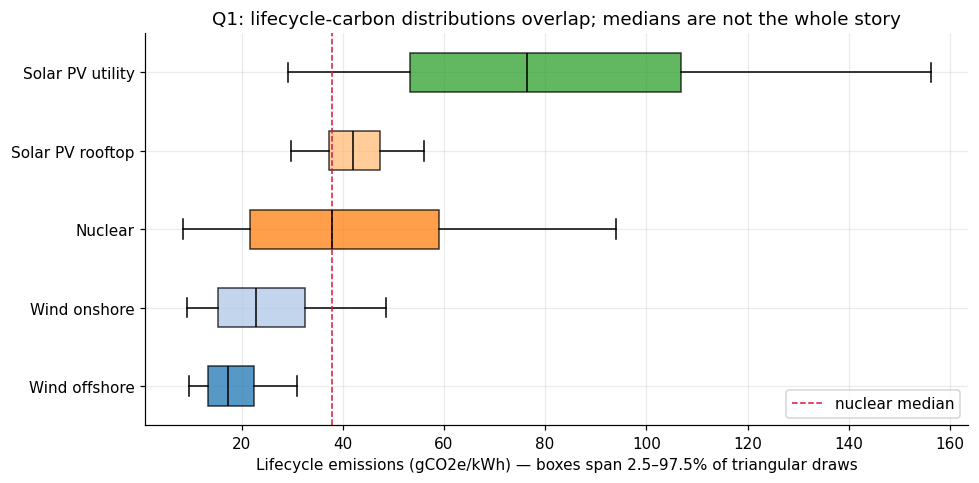

In [2]:
carbon = load_lifecycle_data(PROJECT_ROOT / 'data' / 'lifecycle_emissions_ipcc_ar5.csv')
draws = simulate_uncertainty(carbon, draws=60_000, seed=SEED)
by_tech = {t: g['sampled_gco2e_kwh'].to_numpy() for t, g in draws.groupby('technology')}
order = sorted(by_tech, key=lambda t: np.median(by_tech[t]))

fig, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot([by_tech[t] for t in order], vert=False, whis=(2.5, 97.5),
                showfliers=False, patch_artist=True, medianprops={'color': 'k'})
for patch, t in zip(bp['boxes'], order):
    patch.set_facecolor(tech_color(t)); patch.set_alpha(0.75)
ax.set_yticklabels(order)
ax.set_xlabel('Lifecycle emissions (gCO2e/kWh) — boxes span 2.5–97.5% of triangular draws')
ax.set_title('Q1: lifecycle-carbon distributions overlap; medians are not the whole story')
ax.axvline(np.median(by_tech['Nuclear']), color='crimson', ls='--', lw=1, label='nuclear median')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

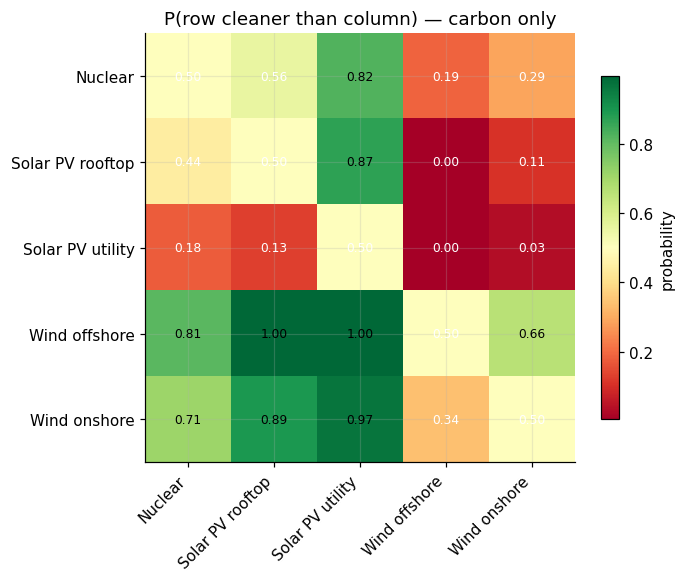

P(onshore wind < nuclear)     = 0.711
P(nuclear < onshore wind)     = 0.289
P(nuclear < utility solar)    = 0.824
distribution overlap nuclear vs onshore wind = 0.63
P(nuclear is the single lowest-carbon of the five) ≈ 0.15


In [3]:
# Pairwise dominance: P(row has strictly lower lifecycle carbon than column).
pm = estimate_pairwise_probabilities(draws)
techs = list(pm.index)
fig, ax = plt.subplots(figsize=(6.4, 5.4))
annotated_heatmap(ax, pm.fillna(0.5).to_numpy(), techs, techs, cmap='RdYlGn',
                  title='P(row cleaner than column) — carbon only')
plt.colorbar(ax.images[0], ax=ax, shrink=0.8, label='probability'); plt.tight_layout(); plt.show()

def overlap(a, b, bins=200):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    ha, _ = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hb, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    return float(np.minimum(ha, hb).sum() * (hi - lo) / bins)

print(f"P(onshore wind < nuclear)     = {pm.loc['Wind onshore','Nuclear']:.3f}")
print(f"P(nuclear < onshore wind)     = {pm.loc['Nuclear','Wind onshore']:.3f}")
print(f"P(nuclear < utility solar)    = {pm.loc['Nuclear','Solar PV utility']:.3f}")
print(f"distribution overlap nuclear vs onshore wind = {overlap(by_tech['Nuclear'], by_tech['Wind onshore']):.2f}")
p_cleanest = np.mean([min(range(len(techs)), key=lambda i: by_tech[techs[i]][k]) == techs.index('Nuclear')
                      for k in rng.integers(0, 60_000, size=5000)])
print(f"P(nuclear is the single lowest-carbon of the five) ≈ {p_cleanest:.2f}")

**Q1 verdict.** Against onshore wind the claim is *false in the median* and unlikely under uncertainty: **P(wind onshore < nuclear) ≈ 0.71** with ~63% distribution overlap, driven by nuclear's long upper tail (max 110 gCO2e/kWh). Nuclear is the single lowest-carbon of the five only ~15% of the time — but it *does* reliably beat solar PV (P ≈ 0.82). So “cleaner than wind **or** solar” is true for solar and false-on-balance for wind: the disjunction does rhetorical work the data don't support.

## Q2 — Once “clean” is operationalised, is there a single winner?

We score 10 technologies on 12 metrics (carbon, deaths, air pollution, waste, water, land, materials, build time, capacity factor, grid integration, cost, financing risk), each with `low/central/high` ranges and a declared direction. Three analyses: (a) **score uncertainty**, (b) **rank robustness**, (c) **global sensitivity over the entire weight simplex** — because the conclusion must not hinge on one hand-picked weighting.

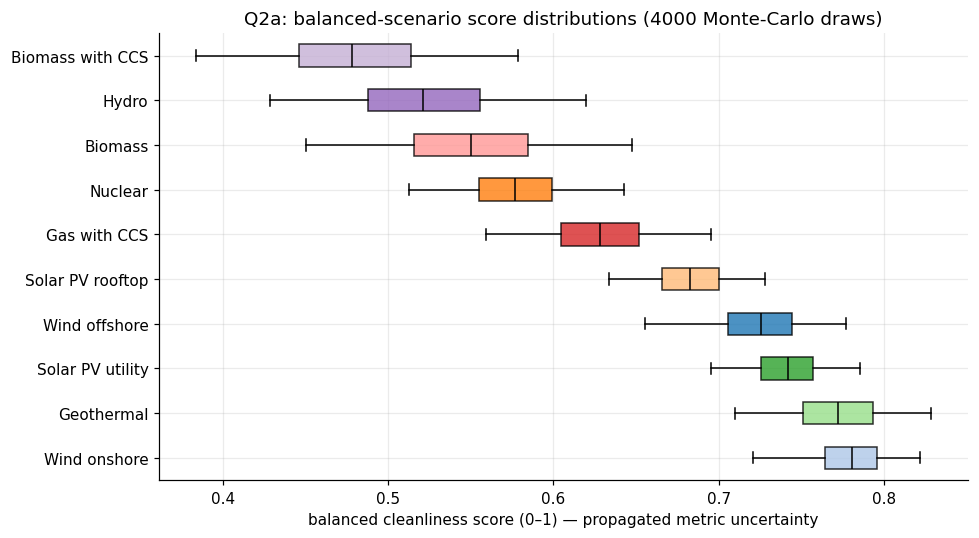

In [4]:
profile = load_multimetric_profile(PROJECT_ROOT / 'data' / 'multimetric_cleanliness_reference.csv')
higher = higher_is_better_set(profile)
wide = to_wide(profile, value='central')
metrics = list(METRIC_UNITS)

mc = monte_carlo_cleanliness(profile, weights=get_scenario('balanced'), samples=4000, seed=SEED, return_draws=True)
sd = mc['score_draws']
order2 = sd.median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([sd[t] for t in order2], vert=False, whis=(2.5, 97.5), showfliers=False,
                patch_artist=True, medianprops={'color': 'k'})
for patch, t in zip(bp['boxes'], order2):
    patch.set_facecolor(tech_color(t)); patch.set_alpha(0.8)
ax.set_yticklabels(order2)
ax.set_xlabel('balanced cleanliness score (0–1) — propagated metric uncertainty')
ax.set_title('Q2a: balanced-scenario score distributions (4000 Monte-Carlo draws)')
plt.tight_layout(); plt.show()

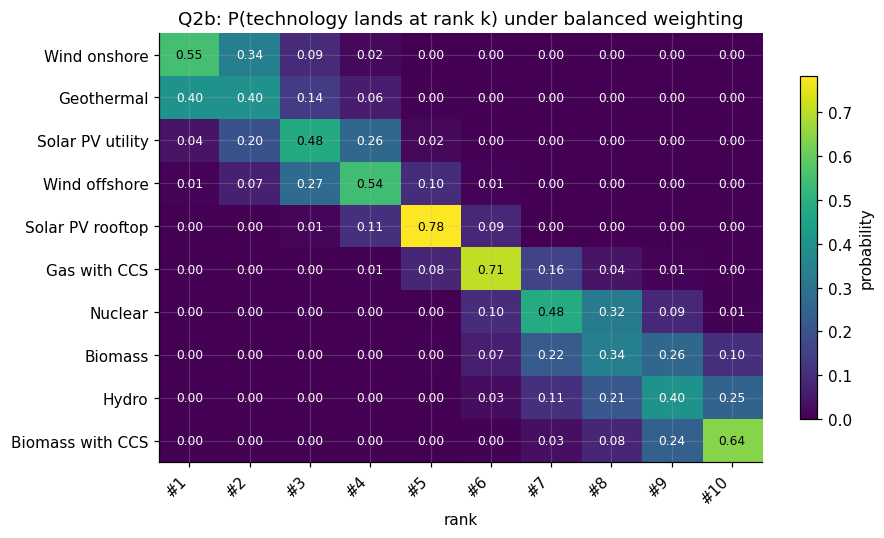

balanced-scenario winner distribution:
Wind onshore        0.550
Geothermal          0.400
Solar PV utility    0.042
Wind offshore       0.008

winner entropy = 1.25 bits (max possible = 3.32); → the "cleanest" title is genuinely contested, not decided.


In [5]:
# Q2b: full rank distribution P(rank = k), richer than top-k counts.
rd = mc['rank_draws']
n = rd.shape[1]
rank_p = np.vstack([[ (rd[t] == k).mean() for k in range(1, n + 1)] for t in order2])
fig, ax = plt.subplots(figsize=(8.5, 5))
annotated_heatmap(ax, rank_p, order2, [f'#{k}' for k in range(1, n + 1)], cmap='viridis',
                  title='Q2b: P(technology lands at rank k) under balanced weighting')
ax.set_xlabel('rank'); plt.colorbar(ax.images[0], ax=ax, shrink=0.8, label='probability')
plt.tight_layout(); plt.show()

winner = rd.idxmin(axis=1)  # rank 1 == smallest rank number
wp = winner.value_counts(normalize=True)
entropy = float(-(wp * np.log2(wp)).sum())
print('balanced-scenario winner distribution:')
print(wp.round(3).to_string())
print(f'\nwinner entropy = {entropy:.2f} bits (max possible = {np.log2(n):.2f}); '
      f'→ the "cleanest" title is genuinely contested, not decided.')

### Q2c — Global sensitivity: who wins across *all* possible weightings?

A single scenario is one point in a 12-dimensional weight simplex. We sample the simplex uniformly (Dirichlet) and record the winner for each weighting. This answers “how large is the slice of preferences under which each technology is ‘cleanest’?” — the honest version of the claim.

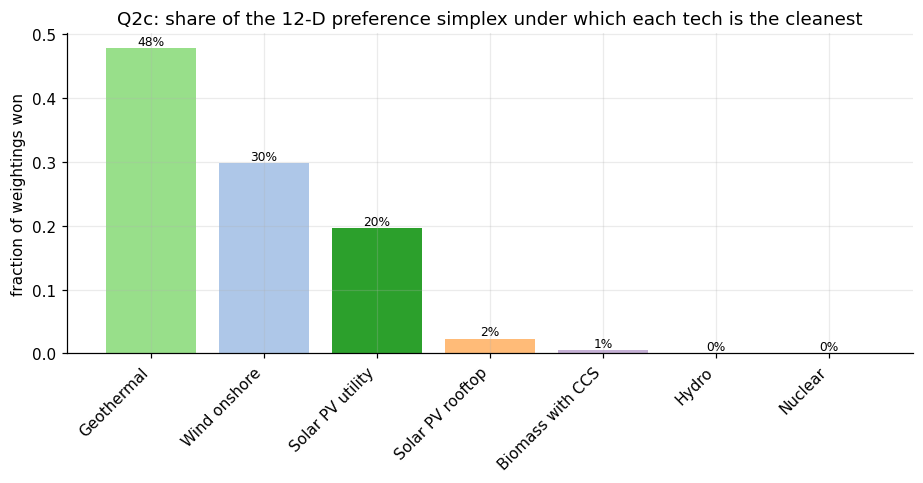

Nuclear wins 0% of all weightings and is top-3 in 7%.
Technologies winning a non-trivial (>5%) share: 3 (['Geothermal', 'Wind onshore', 'Solar PV utility']).


In [6]:
cleaner = normalize_cleanliness_matrix(wide, metrics, method='minmax', higher_is_better=higher)
M = cleaner[metrics].to_numpy()                      # n_tech x n_metric (central values)
tech_names = list(wide['technology'])
W = rng.dirichlet(np.ones(len(metrics)), size=20000)  # uniform over the weight simplex
S = M @ W.T                                            # n_tech x n_draws
winners = np.asarray(tech_names)[S.argmax(axis=0)]
ranks_ws = (-S).argsort(0).argsort(0) + 1
freq = pd.Series(winners).value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
pos = np.arange(len(freq))
ax.bar(pos, freq.values, color=[tech_color(t) for t in freq.index])
ax.set_ylabel('fraction of weightings won')
ax.set_xticks(pos); ax.set_xticklabels(freq.index, rotation=45, ha='right')
ax.set_title("Q2c: share of the 12-D preference simplex under which each tech is the cleanest")
for i, v in enumerate(freq.values):
    ax.text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

nuc = tech_names.index('Nuclear')
top3 = (ranks_ws[nuc] <= 3).mean()
share = freq.get('Nuclear', 0.0)
big = freq[freq > 0.05]
print(f'Nuclear wins {share:.0%} of all weightings and is top-3 in {top3:.0%}.')
print(f'Technologies winning a non-trivial (>5%) share: {len(big)} ({list(big.index)}).')

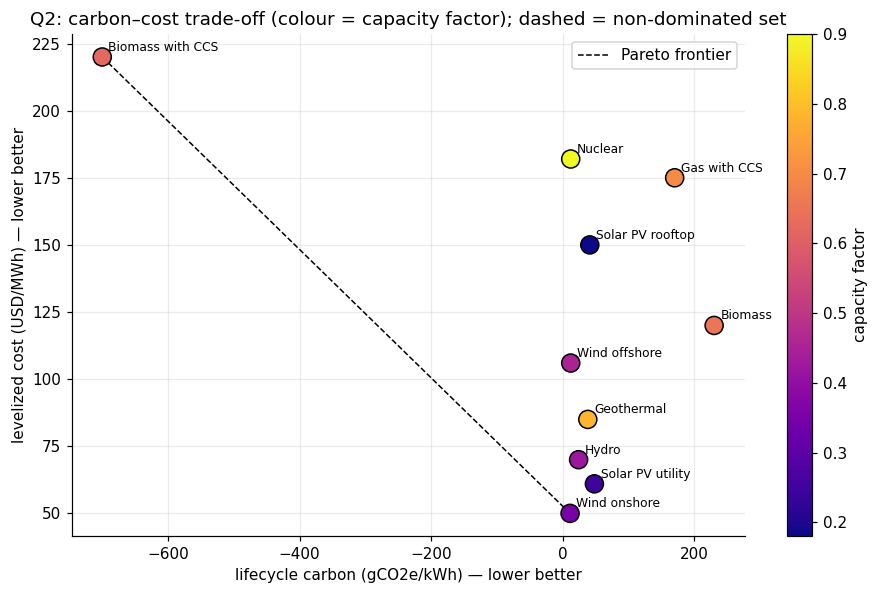

Non-dominated on (carbon, cost): Biomass with CCS, Wind onshore


In [7]:
# Q2 trade-off geometry: objective-space Pareto front (carbon vs cost), reliability encoded.
x = wide['lifecycle_co2e'].to_numpy(); y = wide['levelized_cost'].to_numpy()
cf = wide['capacity_factor'].to_numpy()
dominated = np.array([np.any((x <= xi) & (y <= yi) & ((x < xi) | (y < yi))) for xi, yi in zip(x, y)])
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sc = ax.scatter(x, y, c=cf, s=140, cmap='plasma', edgecolor='k', zorder=3)
front = wide[~dominated].sort_values('lifecycle_co2e')
ax.plot(front['lifecycle_co2e'], front['levelized_cost'], 'k--', lw=1, zorder=2, label='Pareto frontier')
for _, r in wide.iterrows():
    ax.annotate(r['technology'], (r['lifecycle_co2e'], r['levelized_cost']),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('lifecycle carbon (gCO2e/kWh) — lower better')
ax.set_ylabel('levelized cost (USD/MWh) — lower better')
ax.set_title('Q2: carbon–cost trade-off (colour = capacity factor); dashed = non-dominated set')
plt.colorbar(sc, ax=ax, label='capacity factor'); ax.legend(); plt.tight_layout(); plt.show()
print('Non-dominated on (carbon, cost):', ', '.join(front['technology']))

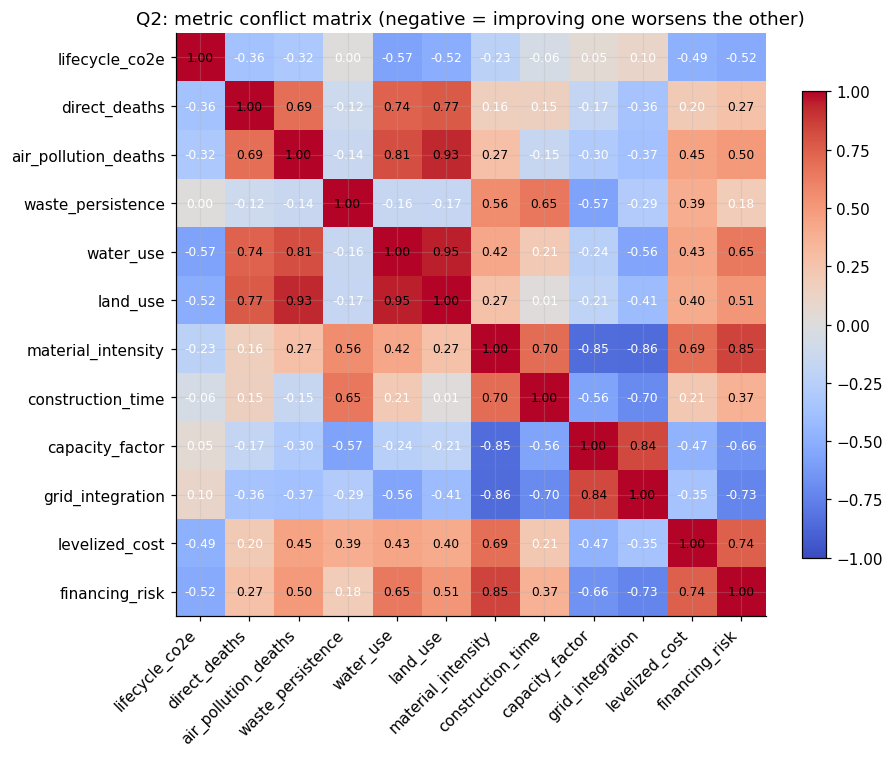

Most conflicting metric pairs (strongest negative correlation):
    material_intensity  vs  grid_integration      r = -0.86
    material_intensity  vs  capacity_factor       r = -0.85
      grid_integration  vs  financing_risk        r = -0.73
     construction_time  vs  grid_integration      r = -0.70


In [8]:
# Which objectives genuinely conflict? Correlation of cleaner-is-higher scores across technologies.
C = np.corrcoef(M.T)
fig, ax = plt.subplots(figsize=(8.5, 7))
annotated_heatmap(ax, C, metrics, metrics, cmap='coolwarm',
                  title='Q2: metric conflict matrix (negative = improving one worsens the other)')
ax.images[0].set_clim(-1, 1); plt.colorbar(ax.images[0], ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
iu = np.triu_indices(len(metrics), 1)
pairs = sorted(zip(C[iu], [(metrics[i], metrics[j]) for i, j in zip(*iu)]))
print('Most conflicting metric pairs (strongest negative correlation):')
for c, (a, b) in pairs[:4]:
    print(f'  {a:>20s}  vs  {b:<20s}  r = {c:+.2f}')

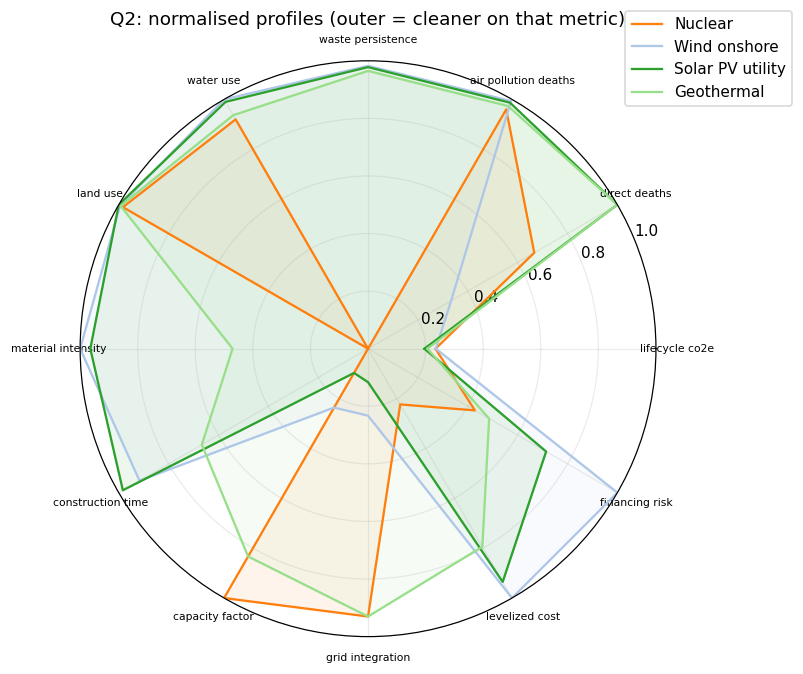

In [9]:
# Profile fingerprints: normalised (cleaner-is-higher) radar for four archetypes.
show = ['Nuclear', 'Wind onshore', 'Solar PV utility', 'Geothermal']
ang = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False)
ang = np.concatenate([ang, ang[:1]])
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={'polar': True})
for t in show:
    vals = cleaner.loc[wide['technology'] == t, metrics].to_numpy().ravel()
    vals = np.concatenate([vals, vals[:1]])
    ax.plot(ang, vals, label=t, color=tech_color(t)); ax.fill(ang, vals, color=tech_color(t), alpha=0.08)
ax.set_xticks(ang[:-1], [m.replace('_', ' ') for m in metrics], fontsize=7)
ax.set_ylim(0, 1); ax.set_title('Q2: normalised profiles (outer = cleaner on that metric)')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1)); plt.tight_layout(); plt.show()

**Q2 verdict.** No technology dominates. Under **uniformly-random weightings** over the 12-metric simplex, **nuclear wins 0% and is top-3 only ~7%**, while onshore wind (~55%) and geothermal (~40%) split the title; only three technologies win a non-trivial share. The objectives genuinely conflict — reliability (capacity factor, grid integration) runs *against* material intensity, build time and financing risk (r ≈ −0.7 to −0.86). A single ranking is not recoverable from the data; it is a choice about values dressed as a fact.

## Q3 — Does the answer survive *where* and *when* you build?

Even fixing a value-weighting, the right choice moves with the system context: the existing grid, the cost of capital, and the deployment year.

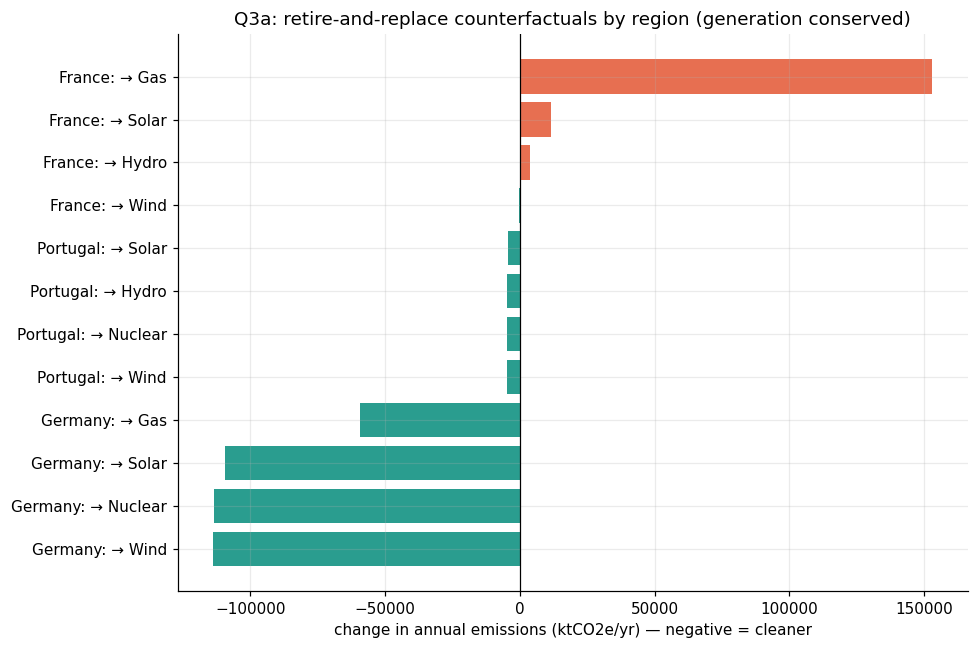

In [10]:
# Q3a: regional counterfactuals — emissions change when a source is retired and replaced.
reg = run_region_scenarios(PROJECT_ROOT / 'data' / 'regions')
moves = reg[reg['replacement'] != ''].copy()
moves['label'] = moves['region'] + ': → ' + moves['replacement']
moves = moves.sort_values('delta_ktco2e')
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2a9d8f' if d < 0 else '#e76f51' for d in moves['delta_ktco2e']]
ax.barh(moves['label'], moves['delta_ktco2e'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('change in annual emissions (ktCO2e/yr) — negative = cleaner')
ax.set_title('Q3a: retire-and-replace counterfactuals by region (generation conserved)')
plt.tight_layout(); plt.show()

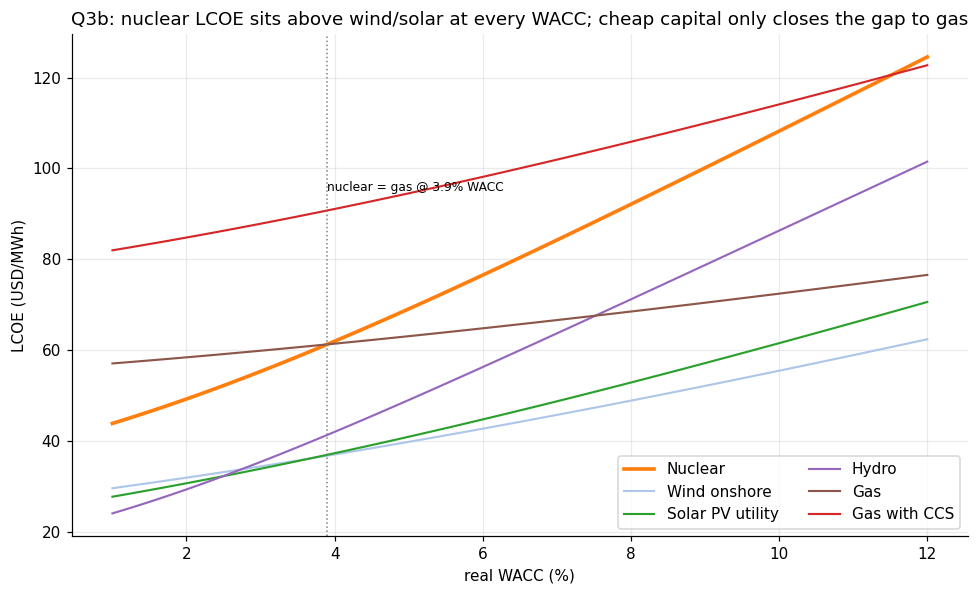

Break-even WACC where nuclear LCOE equals:
  Solar PV utility  : nuclear stays more expensive across 1-12%
  Wind onshore      : nuclear stays more expensive across 1-12%
  Gas               : 3.9%


In [11]:
# Q3b: cost of capital. LCOE vs WACC; nuclear never undercuts wind/solar here, only closes the gap to gas.
waccs = np.linspace(0.01, 0.12, 111)
curves = {name: np.array([lcoe(te, w) for w in waccs]) for name, te in DEFAULT_TECHNO_ECONOMICS.items()}

def breakeven(a, b):
    d = curves[a] - curves[b]
    s = np.where(np.diff(np.sign(d)) != 0)[0]
    if not len(s):
        return None
    i = s[0]
    return float(waccs[i] - d[i] * (waccs[i + 1] - waccs[i]) / (d[i + 1] - d[i]))

fig, ax = plt.subplots(figsize=(9, 5.5))
for name in ['Nuclear', 'Wind onshore', 'Solar PV utility', 'Hydro', 'Gas', 'Gas with CCS']:
    ax.plot(waccs * 100, curves[name], label=name, lw=2.4 if name == 'Nuclear' else 1.4, color=tech_color(name))
be_gas = breakeven('Nuclear', 'Gas')
if be_gas:
    ax.axvline(be_gas * 100, color='grey', ls=':', lw=1)
    ax.annotate(f'nuclear = gas @ {be_gas*100:.1f}% WACC', (be_gas * 100, 95), fontsize=8, ha='left')
ax.set_xlabel('real WACC (%)'); ax.set_ylabel('LCOE (USD/MWh)')
ax.set_title('Q3b: nuclear LCOE sits above wind/solar at every WACC; cheap capital only closes the gap to gas')
ax.legend(ncol=2); plt.tight_layout(); plt.show()
print('Break-even WACC where nuclear LCOE equals:')
for other in ['Solar PV utility', 'Wind onshore', 'Gas']:
    be = breakeven('Nuclear', other)
    print(f'  {other:<18s}: {be*100:.1f}%' if be else f'  {other:<18s}: nuclear stays more expensive across 1-12%')

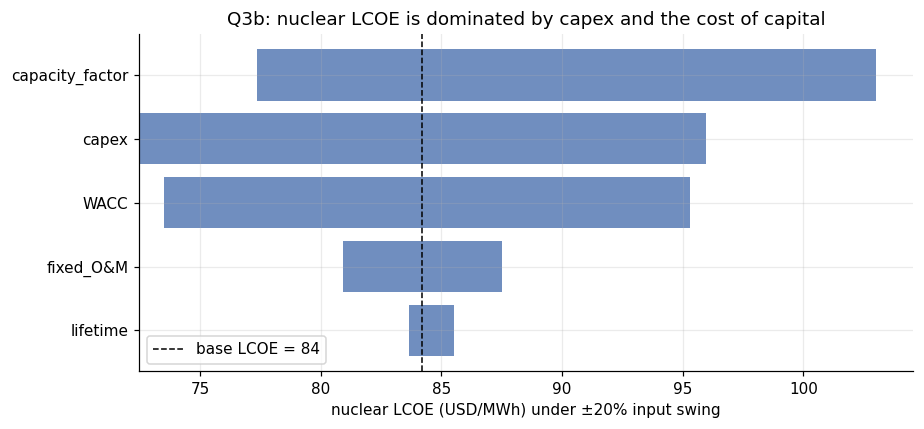

In [12]:
# Q3b: tornado — what drives nuclear LCOE? One-at-a-time ±20% perturbations at WACC = 7%.
from dataclasses import replace
base = DEFAULT_TECHNO_ECONOMICS['Nuclear']; w0 = 0.07; base_lcoe = lcoe(base, w0)
drivers, lows, highs = [], [], []
for field, lo_hi in {
    'capex': ('capex_usd_per_kw', None), 'capacity_factor': ('capacity_factor', None),
    'lifetime': ('lifetime_years', None), 'fixed_O&M': ('fixed_om_usd_per_kw_yr', None),
}.items():
    f = lo_hi[0]; v = getattr(base, f)
    hi_v = min(v * 1.2, 0.99) if f == 'capacity_factor' else v * 1.2
    lo = lcoe(replace(base, **{f: v * 0.8}), w0); hi = lcoe(replace(base, **{f: hi_v}), w0)
    drivers.append(field); lows.append(min(lo, hi)); highs.append(max(lo, hi))
lo_w = lcoe(base, w0 * 0.8); hi_w = lcoe(base, w0 * 1.2)
drivers.append('WACC'); lows.append(min(lo_w, hi_w)); highs.append(max(lo_w, hi_w))
tor = pd.DataFrame({'driver': drivers, 'low': lows, 'high': highs})
tor['span'] = tor['high'] - tor['low']; tor = tor.sort_values('span')
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(tor['driver'], tor['high'] - tor['low'], left=tor['low'], color='#4c72b0', alpha=0.8)
ax.axvline(base_lcoe, color='k', ls='--', lw=1, label=f'base LCOE = {base_lcoe:.0f}')
ax.set_xlabel('nuclear LCOE (USD/MWh) under ±20% input swing')
ax.set_title('Q3b: nuclear LCOE is dominated by capex and the cost of capital')
ax.legend(); plt.tight_layout(); plt.show()

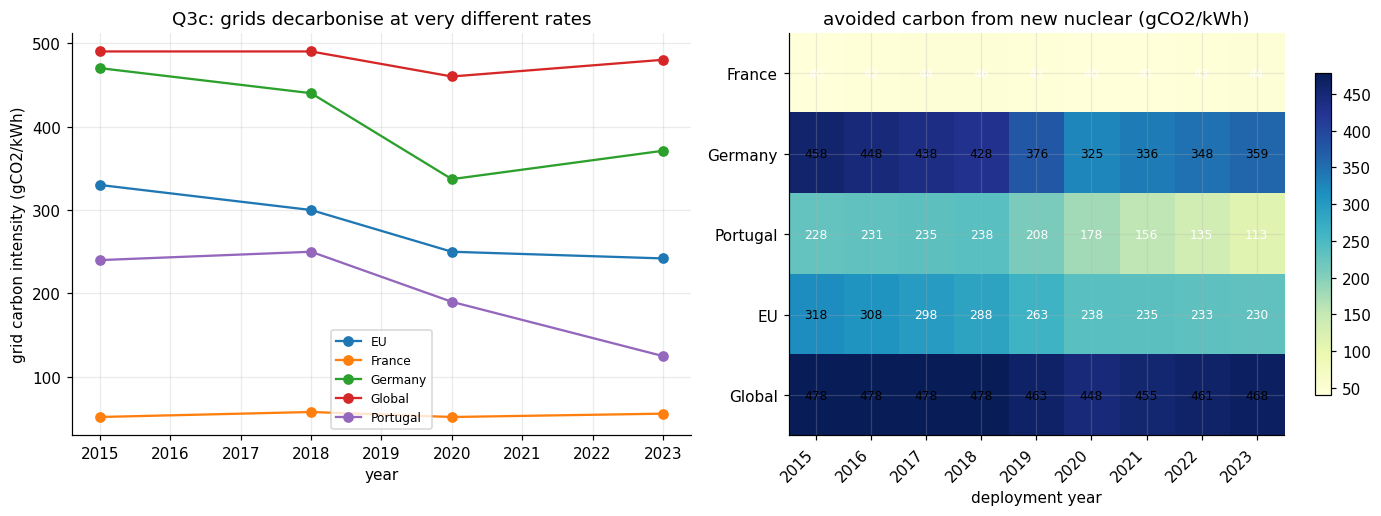

Marginal abatement of new nuclear (gCO2/kWh):
  Germany   2015 -> 2023 : 458 -> 359
  France    2015 -> 2023 : 40 -> 44
Ranking of clean techs by abatement is grid-independent (constant lifecycle offset);
only the *magnitude* of the benefit depends on geography and year.


In [13]:
# Q3c: grid context and deployment year — marginal carbon a clean build avoids.
grid = load_grid_intensity(PROJECT_ROOT / 'data' / 'grid_carbon_intensity.csv')
traj = trajectory_table(grid)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for r, g in traj.groupby('region'):
    axes[0].plot(g['year'], g['grid_gco2_kwh'], marker='o', label=r)
axes[0].set_ylabel('grid carbon intensity (gCO2/kWh)'); axes[0].set_xlabel('year')
axes[0].set_title('Q3c: grids decarbonise at very different rates'); axes[0].legend(fontsize=8)

nuc_life = float(wide.loc[wide['technology'] == 'Nuclear', 'lifecycle_co2e'].iloc[0])
regions_list = ['France', 'Germany', 'Portugal', 'EU', 'Global']
years = list(range(2015, 2024))
A = np.array([[grid_intensity(grid, r, y) - nuc_life for y in years] for r in regions_list])
im = annotated_heatmap(axes[1], A, regions_list, [str(y) for y in years], fmt='{:.0f}',
                       cmap='YlGnBu', title='avoided carbon from new nuclear (gCO2/kWh)')
axes[1].set_xlabel('deployment year'); plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()

print('Marginal abatement of new nuclear (gCO2/kWh):')
for r in ['Germany', 'France']:
    print(f'  {r:<9s} 2015 -> 2023 : {A[regions_list.index(r),0]:.0f} -> {A[regions_list.index(r),-1]:.0f}')
print('Ranking of clean techs by abatement is grid-independent (constant lifecycle offset);')
print('only the *magnitude* of the benefit depends on geography and year.')

## Synthesis — a decision map, not a ranking

The defensible output is not “X is cleanest” but a mapping from *(what you value, where, under what financing)* to the best choice. Below: the multi-metric winner for each policy intent, and a coarse cost-winner by cost-of-capital regime.

In [14]:
from energy_cleanliness.cleanliness_index import weighted_cleanliness_score
rows = []
for name in SCENARIOS:
    s = weighted_cleanliness_score(wide, metrics=metrics, weights=get_scenario(name), higher_is_better=higher)
    rows.append({'context': f'value: {name}', 'winner': s.iloc[0]['technology'],
                 'runner_up': s.iloc[1]['technology']})
build_techs = ['Nuclear', 'Wind onshore', 'Solar PV utility', 'Hydro', 'Gas', 'Gas with CCS', 'Geothermal']
for env in DEFAULT_ENVIRONMENTS.values():
    costs = {t: lcoe(DEFAULT_TECHNO_ECONOMICS[t], env.wacc) for t in build_techs}
    ranked = sorted(costs, key=costs.get)
    rows.append({'context': f'cheapest @ WACC {env.wacc:.1%}', 'winner': ranked[0], 'runner_up': ranked[1]})
decision = pd.DataFrame(rows)
decision

,context,winner,runner_up
0,value: balanced,Geothermal,Solar PV utility
1,value: low_emissions_first,Geothermal,Wind onshore
2,value: low_cost_first,Wind onshore,Solar PV utility
3,value: high_reliability_first,Geothermal,Nuclear
4,cheapest @ WACC 3.0%,Solar PV utility,Wind onshore
5,cheapest @ WACC 5.0%,Wind onshore,Solar PV utility
6,cheapest @ WACC 10.0%,Wind onshore,Solar PV utility


## Conclusion

1. **Carbon (Q1):** nuclear is *not* unambiguously cleaner than wind — onshore wind has the lower IPCC median, the distributions overlap ~63%, and wind is the lower-carbon option in ~71% of draws (nuclear's long tail to 110 gCO2e/kWh is the cause). Nuclear does beat solar PV. The claim is true for the easy comparison and false-on-balance for the hard one, hidden by an “or”.
2. **Definition (Q2):** with “clean” operationalised over 12 metrics there is no dominant technology; nuclear wins **0%** of uniformly-random weightings, the title splits between wind and geothermal, and the key objectives conflict. A single ranking is a values choice, not a measurement.
3. **Context (Q3):** the best option moves with the grid it displaces, the cost of capital (nuclear's LCOE stays above wind and solar at every plausible WACC and only undercuts gas when capital is cheap), and the deployment year.

> **Bottom line.** Nuclear, wind and solar are all low-carbon. “Nuclear is cleaner, and the data confirm it” is not a finding the data support: it conflates carbon with cleanliness, suppresses uncertainty, ignores conflicting objectives, and erases geography, financing and time. The honest output is a decision map — and on its most-cited axis, carbon, wind (not nuclear) is the more likely lower-carbon choice.

### Methods, assumptions & limitations

- **Uncertainty** is modelled with triangular `(low, central, high)` proxies, not reconstructed literature distributions; it is a transparency device, deliberately wide.
- **Normalisation** is per-draw min-max across the compared set; adding/removing a technology shifts every normalised score (shown limitation, not a bug).
- **Provenance:** carbon = IPCC AR5; cost = Lazard v17; grid intensity = Ember/EEA-consistent; other non-carbon metrics, techno-economics and region WACCs are literature-informed proxies (see `data/data_sources.md`). Treat directions and *magnitudes of difference* as robust, point values as illustrative.
- **Financing** uses a CRF/WACC LCOE with representative techno-economics; it captures the *direction and size* of cost-of-capital effects, not project-specific costs.
- **Counterfactuals** conserve generation and ignore system effects (storage, transmission, dispatch, reserves).

In [15]:
# Reproducibility footer: seed, library versions, and content hashes of every input dataset.
def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()[:12]
inputs = ['data/lifecycle_emissions_ipcc_ar5.csv', 'data/multimetric_cleanliness_reference.csv',
          'data/grid_carbon_intensity.csv']
print(f'seed={SEED} | python {platform.python_version()} | numpy {np.__version__} | '
      f'pandas {pd.__version__} | matplotlib {mpl.__version__}\n')
for p in inputs:
    print(f'  sha256[:12] {sha(PROJECT_ROOT / p)}  {p}')
print('\nRe-run top-to-bottom to reproduce every figure and number above.')

seed=42 | python 3.13.5 | numpy 2.3.5 | pandas 2.3.3 | matplotlib 3.10.8

  sha256[:12] 8fc5d333474a  data/lifecycle_emissions_ipcc_ar5.csv
  sha256[:12] ec04386fc7c5  data/multimetric_cleanliness_reference.csv
  sha256[:12] 42539f095a3d  data/grid_carbon_intensity.csv

Re-run top-to-bottom to reproduce every figure and number above.
